# ¡Hola Jhovanna! ¿Cómo estás? 🙂
<div class="alert alert-block alert-info">
   
Mi nombre es <b>Andrés Barbosa</b> 👋 

Un gusto conocerte, seré tu revisor en este proyecto.
A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:
Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y
corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para
mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.
Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más
precisa, junto con algunos ejemplos prácticos. También estoy abierto a responder cualquier duda que
tengas.
Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.
Puedes encontrar mis comentarios en cuadros verdes, amarillos o rojos como este:
</div>
<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>
Éxito. Todo se ha hecho de forma correcta.
</div>
<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>
Observación. Algunas recomendaciones o mejoras menores.
</div>
<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>
Necesita arreglos. Este apartado requiere algunas correcciones. El trabajo no puede ser aceptado
con comentarios rojos.
</div>
<div class="alert alert-block alert-info">
Puedes responder utilizando este formato:
Respuesta del estudiante.
</div>

Empecemos! 🚀

<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b><br><br>¡Hol Jhovanna! Excelente trabajo. Revisé el notebook completo y es un análisis muy riguroso y bien documentado: la limpieza y validación de los datos, el análisis exploratorio, la construcción de métricas por operador, la identificación de los operadores potencialmente ineficaces con criterios explícitos, las pruebas de hipótesis y una sección de limitaciones muy honesta. Verifiqué las cifras principales contra las salidas y coinciden. <b>Proyecto aprobado.</b><br><br>Cada decisión metodológica está justificada en el texto, y el análisis termina en una herramienta de priorización clara para los supervisores. Te dejo comentarios en verde de lo que hiciste bien y un matiz metodológico menor. ¡Felicitaciones!
</div>

# Telecomunicaciones: identificar operadores ineficaces

PROYECTO FINAL; https://drive.google.com/file/d/1pohvsb0DOOQDDIhXZEagOknBTk42OP6T/view?usp=drive_link
PRESENTACION PDF; https://docs.google.com/document/d/12PaOLj2n7y-z79QkwDnhCdO2_zaa1PsY1ujZz8a8tSk/edit?usp=sharing


### Ejercicio

El servicio de telefonía virtual CallMeMaybe está desarrollando una nueva función que brindará a los supervisores y las supervisores información sobre los operadores menos eficaces. Se considera que un operador es ineficaz si tiene una gran cantidad de llamadas entrantes perdidas (internas y externas) y un tiempo de espera prolongado para las llamadas entrantes. Además, si se supone que un operador debe realizar llamadas salientes, un número reducido de ellas también será un signo de ineficacia.

* Lleva a cabo el análisis exploratorio de datos
* Identificar operadores ineficaces
* Prueba las hipótesis estadísticas



### Descripción de los datos

Los datasets contienen información sobre el uso del servicio de telefonía virtual CallMeMaybe. Sus clientes son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores, o realizar llamadas salientes a través de sus operadores. Los operadores también pueden realizar llamadas internas para comunicarse entre ellos. Estas llamadas se realizan a través de la red de CallMeMaybe.

El dataset comprimido `telecom_dataset_us.csv` contiene las siguientes columnas:

- `user_id`: ID de la cuenta de cliente
- `date`: fecha en la que se recuperaron las estadísticas
- `direction`: "dirección" de llamada (`out` para saliente, `in` para entrante)
- `internal`: si la llamada fue interna (entre los operadores de un cliente o clienta)
- `operator_id`: identificador del operador
- `is_missed_call`: si fue una llamada perdida
- `calls_count`: número de llamadas
- `call_duration`: duración de la llamada (sin incluir el tiempo de espera)
- `total_call_duration`: duración de la llamada (incluido el tiempo de espera)


El conjunto de datos `telecom_clients_us.csv` tiene las siguientes columnas:

- `user_id`: ID de usuario/a
- `tariff_plan`: tarifa actual de la clientela
- `date_start`: fecha de registro de la clientela

## Paso 1. Librerias

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.cluster import KMeans
from scipy.stats import mannwhitneyu
from scipy.cluster.hierarchy import dendrogram, linkage

## Paso 2. Importar los datasets

In [120]:
# Cargar el arvhivo de datos.
df = pd.read_csv('/datasets/telecom_dataset_us.csv')
df_clients = pd.read_csv('/datasets/telecom_clients_us.csv')

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [122]:
df.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [123]:
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [124]:
df_clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


## Paso 3. Limpieza de datos

In [125]:
# Convertir columnas de fecha a Datetime.
df['date'] = pd.to_datetime(df['date'])
df_clients['date_start'] = pd.to_datetime(df_clients['date_start'])

In [126]:
# Revisar valores ausentes
df.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [127]:
df_clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [128]:
# Revisar si hay duplicados
df.duplicated().sum()

4900

In [129]:
df.shape

(53902, 9)

In [130]:
df_clients.duplicated().sum()

0

In [131]:
# Esto nos permitirá confirmar exactamente 
# cuántos registros tendremos después de eliminar duplicados.
df.drop_duplicates().shape

(49002, 9)

In [132]:
# Eliminar registros duplicados
df = df.drop_duplicates().reset_index(drop=True)

In [133]:
# Comprobamos que ya no haya duplicados:
df.duplicated().sum()

0

Se identificaron 4,900 registros duplicados exactos en el dataset de llamadas. Estos registros se eliminaron para evitar que las mismas observaciones influyeran varias veces en los resultados del análisis. El dataset pasó de 53,902 a 49,002 registros.

In [134]:
# revisemos los problemas de valores ausentes (internal)
df[df['internal'].isna()][
    ['direction', 'operator_id', 'is_missed_call', 'calls_count']
].head(20)

,direction,operator_id,is_missed_call,calls_count
917,in,NaN,True,1
996,in,NaN,True,1
1705,in,NaN,True,1
1761,in,879898.0,False,1
5645,in,908960.0,False,1
5651,in,908958.0,False,2
6841,in,NaN,True,1
6846,in,893402.0,False,1
7862,in,890404.0,False,1
8245,in,890404.0,False,1


In [135]:
df[df['internal'].isna()]['direction'].value_counts()

in     108
out      2
Name: direction, dtype: int64

La variable internal presentó 117 valores ausentes. Al revisar estas observaciones, se comprobó que corresponden principalmente a llamadas entrantes (108 casos) y que no existe una relación suficientemente clara entre el valor ausente y una categoría específica. Por ello, se decidió conservar los valores ausentes en lugar de imputarlos, evitando introducir una clasificación que no está respaldada por los datos.

In [136]:
# Revisar la columna calls_count
df[df['calls_count'].isna()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration


In [137]:
df[df['calls_count'] <= 0][['calls_count', 'direction', 'is_missed_call']]

,calls_count,direction,is_missed_call


In [138]:
df['calls_count'].value_counts().sort_index().head(20)

1     13061
2      6392
3      4059
4      3032
5      2233
6      1763
7      1517
8      1265
9      1074
10      977
11      813
12      733
13      652
14      613
15      532
16      486
17      430
18      378
19      371
20      373
Name: calls_count, dtype: int64

In [139]:
df['calls_count'].min(), df['calls_count'].max()

(1, 4817)

La variable calls_count no presentó valores iguales o inferiores a cero. El mínimo fue de 1 llamada y el máximo de 4,817. Aunque existen valores elevados, no se eliminaron al no existir evidencia suficiente para considerarlos errores de registro.

In [140]:
# Revision de la duracion de llamadas
(df['total_call_duration'] < df['call_duration']).sum()

0

In [141]:
# Analizar call_duration y total_call_duration
df[['call_duration', 'total_call_duration']].describe(
    percentiles=[.25, .5, .75, .9, .95, .99]
)

,call_duration,total_call_duration
count,49002.000000,49002.000000
mean,866.282091,1156.558202
std,3775.503352,4451.473661
min,0.000000,0.000000
25%,0.000000,46.000000
50%,37.000000,208.000000
75%,570.000000,901.000000
90%,2092.000000,2610.800000
95%,3725.950000,4531.000000
99%,10314.910000,12956.000000


In [142]:
# Crear la variable waiting_time como la diferencia entre total_call_duration y call_duration
# y asi Calcular posteriormente el tiempo de espera
df['waiting_time'] = (df['total_call_duration'] - df['call_duration'])

In [143]:
df['waiting_time'].describe(percentiles=[.25, .5, .75, .9, .95, .99])

count    49002.000000
mean       290.276111
std       1132.155291
min          0.000000
25%         17.000000
50%         55.000000
75%        200.000000
90%        613.000000
95%       1163.000000
99%       3157.910000
max      46474.000000
Name: waiting_time, dtype: float64

In [144]:
(df['waiting_time'] < 0).sum()

0

Se creó la variable waiting_time como la diferencia entre total_call_duration y call_duration, con el objetivo de medir el tiempo que los clientes permanecieron esperando antes de ser atendidos. La variable no presentó valores negativos. La mediana fue de 55 segundos, mientras que el percentil 95 alcanzó 1,163 segundos, lo que muestra una distribución sesgada y la presencia de valores extremos. Estos valores se conservaron debido a que los tiempos de espera elevados son relevantes para el objetivo del análisis.

In [145]:
# Revisar valores booleanos y categóricos
df['direction'].value_counts()

out    28999
in     20003
Name: direction, dtype: int64

In [146]:
df['internal'].value_counts(dropna=False)

False    43239
True      5653
NaN        110
Name: internal, dtype: int64

In [147]:
df['is_missed_call'].value_counts()

False    27549
True     21453
Name: is_missed_call, dtype: int64

In [148]:
# Revisar el periodo de llamadas (fecha)
df['date'].min(), df['date'].max()

(Timestamp('2019-08-02 00:00:00+0300', tz='pytz.FixedOffset(180)'),
 Timestamp('2019-11-28 00:00:00+0300', tz='pytz.FixedOffset(180)'))

In [149]:
# Revisar el periodo de registro de clientes
df_clients['date_start'].min(), df_clients['date_start'].max()

(Timestamp('2019-08-01 00:00:00'), Timestamp('2019-10-31 00:00:00'))

In [150]:
# Asegurarnos de que los user_id del dataset de llamadas correspondan a clientes existentes
df['user_id'].nunique()

307

In [151]:
df_clients['user_id'].nunique()

732

In [152]:
# Y también revisamos operadores
# Esto es importante porque operator_id es nuestra unidad principal de análisis
df['operator_id'].nunique()

1092

In [153]:
# Revisemos los NaN operator_id
df[df['operator_id'].isna()][
    ['direction', 'is_missed_call', 'calls_count', 'call_duration']
].groupby(
    ['direction', 'is_missed_call']
).agg(
    records=('calls_count', 'size'),
    calls=('calls_count', 'sum')
)

records   calls
direction is_missed_call                 
in        False                68     646
          True               7202  103397
out       False                45     319
          True                141     202

La variable operator_id presentó 8,172 valores ausentes. Al analizar estas observaciones, se encontró que la mayoría correspondía a llamadas entrantes perdidas: 7,202 registros. Esto es consistente con situaciones en las que una llamada no fue atendida y, por lo tanto, no se asignó a un operador.

Sin embargo, también se identificaron algunas llamadas atendidas sin operator_id, por lo que no se imputaron valores ni se asumió un operador. Los registros se conservaron en el dataset original y, para el análisis de desempeño individual, se utilizaron únicamente las llamadas asociadas a un operador identificado.

In [154]:
# Validacion de clientes
df_check = df.merge(
    df_clients[['user_id', 'date_start']],
    on='user_id',
    how='left'
)

(df_check['date'].dt.tz_localize(None) < df_check['date_start']).sum()

0

No se encontraron registros de llamadas anteriores a la fecha de inicio de los clientes.

Conclusion:

Inicialmente, el dataset de llamadas contenía 53,902 registros. Durante la revisión de calidad se identificaron 4,900 registros duplicados exactos, los cuales fueron eliminados, dejando 49,002 registros para el análisis.

Las variables date y date_start fueron convertidas al formato de fecha. Se revisaron los valores ausentes de internal y operator_id. Los valores ausentes de internal se conservaron debido a que no fue posible determinar de forma confiable su categoría. Los valores ausentes de operator_id también se conservaron, ya que la mayoría corresponde a llamadas entrantes perdidas sin operador asignado y son relevantes para el análisis general.

Se verificó que calls_count no contiene valores iguales o menores que cero. También se comprobó que total_call_duration nunca es menor que call_duration. A partir de estas variables se creó waiting_time, que tampoco presentó valores negativos.

Los valores extremos de duración y número de llamadas no fueron eliminados automáticamente, ya que pueden representar situaciones reales y son relevantes para el análisis del desempeño de los operadores.

Finalmente, se comprobó la consistencia entre los datasets mediante user_id: los 49,002 registros de llamadas corresponden a clientes presentes en el dataset de clientes

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b><br><br>Muy buena la limpieza y validación de los datos. Detectás y eliminás los 4.900 duplicados exactos (de 53.902 a 49.002 registros), convertís las fechas, y el tratamiento de los valores ausentes es muy acertado. En especial, el análisis de <code>operator_id</code>: mostrás que la mayoría de los 8.172 nulos son llamadas entrantes perdidas (7.202) que por naturaleza no tienen operador, así que los conservás en el dataset general pero los excluís del análisis por operador. Además verificás que <code>total_call_duration</code> nunca sea menor que <code>call_duration</code> antes de derivar el tiempo de espera. Un trabajo de calidad muy prolijo.
</div>

In [155]:
print('Filas finales:', len(df))
print('Duplicados:', df.duplicated().sum())
print('Clientes en llamadas:', df['user_id'].nunique())
print('Clientes en catálogo:', df_clients['user_id'].nunique())
print('Operadores identificados:', df['operator_id'].nunique())
print('Valores negativos en waiting_time:', (df['waiting_time'] < 0).sum())
print('Total < duración:', (df['total_call_duration'] < df['call_duration']).sum())

Filas finales: 49002
Duplicados: 0
Clientes en llamadas: 307
Clientes en catálogo: 732
Operadores identificados: 1092
Valores negativos en waiting_time: 0
Total < duración: 0


## Paso 4. Análisis exploratorio de datos (EDA)

In [156]:
print('Periodo:', df['date'].min(), '→', df['date'].max())
print('Registros:', len(df))
print('Clientes con llamadas:', df['user_id'].nunique())
print('Operadores identificados:', df['operator_id'].nunique())

Periodo: 2019-08-02 00:00:00+03:00 → 2019-11-28 00:00:00+03:00
Registros: 49002
Clientes con llamadas: 307
Operadores identificados: 1092


In [157]:
# LLamadas entrantes perdidas vs salientes en porcentaje
incoming_calls = df[df['direction'] == 'in']

incoming_missed_rate = (
    incoming_calls.loc[
        incoming_calls['is_missed_call'], 
        'calls_count'
    ].sum()
    /
    incoming_calls['calls_count'].sum()
    * 100
)

print(f'Volumen de llamadas entrantes perdidas: {incoming_missed_rate:.2f}%')

Volumen de llamadas entrantes perdidas: 52.73%


In [158]:
outgoing_calls = df[df['direction'] == 'out']

outgoing_missed_rate = (
    outgoing_calls.loc[
        outgoing_calls['is_missed_call'],
        'calls_count'
    ].sum()
    /
    outgoing_calls['calls_count'].sum()
    * 100
)

print(f'Volumen de llamadas salientes perdidas: {outgoing_missed_rate:.2f}%')

Volumen de llamadas salientes perdidas: 44.61%


Del total de llamadas entrantes, el 52.73% fueron llamadas perdidas, frente al 44.61% de las llamadas salientes. La elevada proporción de llamadas entrantes perdidas constituye una señal relevante para el análisis posterior del desempeño de los operadores.

In [159]:
# Analizar nuevamente las llamadas entrantes vs salientes en porcentajes
missed_calls = df.groupby(
    ['direction', 'is_missed_call']
)['calls_count'].sum().unstack(fill_value=0)

missed_calls['total_calls'] = missed_calls[False] + missed_calls[True]

missed_calls['missed_rate_pct'] = (
    missed_calls[True] /
    missed_calls['total_calls'] * 100
).round(2)

missed_calls

is_missed_call,False,True,total_calls,missed_rate_pct
direction,,,,
in,93522,104323,197845,52.73
out,337269,271595,608864,44.61


Esto nos permitirá decir si el servicio tiene mayor actividad saliente no solamente en número de registros, sino también en volumen real de llamadas.

In [160]:
# Llamadas perdidas y atendidas por dirección
pivot_missed = (
    df.groupby(['direction', 'is_missed_call'])['calls_count']
    .sum()
    .unstack(fill_value=0)
    .rename(columns={
        False: 'Atendidas',
        True: 'Perdidas'
    })
)

pivot_missed

is_missed_call,Atendidas,Perdidas
direction,,
in,93522,104323
out,337269,271595


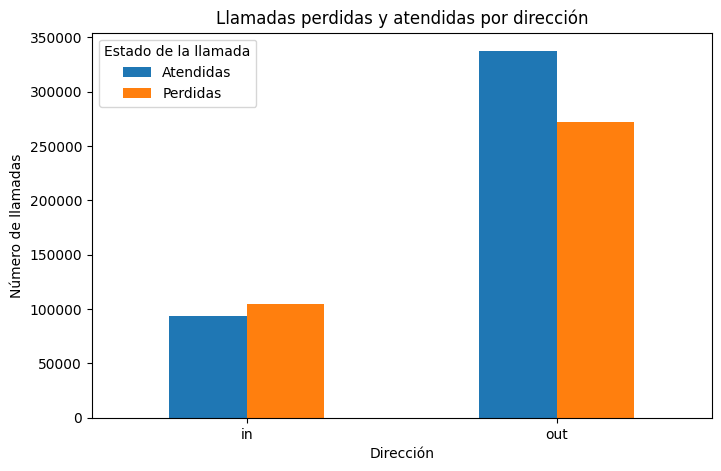

In [161]:
# Grafico de Llamadas perdidas y atendidas por dirección
pivot_missed.plot(kind='bar', figsize=(8, 5))
plt.title('Llamadas perdidas y atendidas por dirección')
plt.xlabel('Dirección')
plt.ylabel('Número de llamadas')
plt.legend(title='Estado de la llamada')
plt.xticks(rotation=0)
plt.show()

El volumen de llamadas presenta diferencias importantes según la dirección. En las llamadas entrantes, el número de llamadas perdidas supera al de llamadas atendidas, mientras que en las llamadas salientes ocurre lo contrario. Esto sugiere que la gestión de llamadas entrantes requiere especial atención y justifica analizar posteriormente la tasa de llamadas perdidas y el tiempo de espera por operador.

In [162]:
# Calcula la tasa de llamdas perdidas por direccion
missed_rate = (
    df.groupby('direction')
      .apply(lambda x: x.loc[x['is_missed_call'], 'calls_count'].sum() / x['calls_count'].sum() * 100)
)

missed_rate

direction
in     52.729662
out    44.606842
dtype: float64

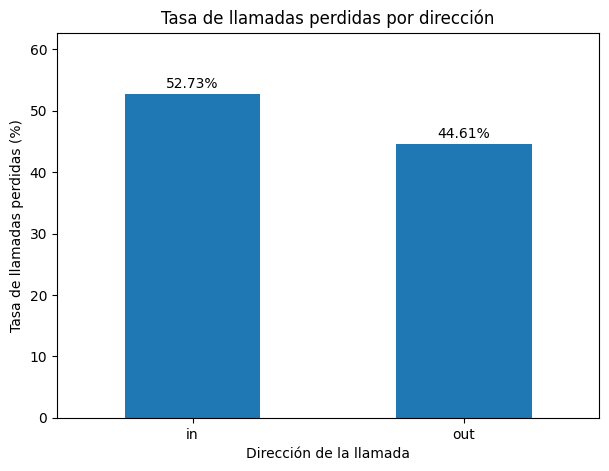

In [163]:
# Grafica de llamadas perdidas por dirección
plt.figure(figsize=(7, 5))

missed_rate.plot(kind='bar')

plt.title('Tasa de llamadas perdidas por dirección')
plt.xlabel('Dirección de la llamada')
plt.ylabel('Tasa de llamadas perdidas (%)')
plt.xticks(rotation=0)

# Mostrar los porcentajes encima de las barras
for i, value in enumerate(missed_rate):
    plt.text(i, value + 1, f'{value:.2f}%', ha='center')

plt.ylim(0, max(missed_rate) + 10)

plt.show()


La tasa de llamadas perdidas es mayor en las llamadas entrantes (52.73%) que en las salientes (44.61%). Esto indica que las llamadas entrantes presentan un mayor nivel de pérdida y, por lo tanto, requieren especial atención en el análisis del desempeño de los operadores.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b><br><br>Muy buen análisis exploratorio. Distinguís bien las llamadas entrantes de las salientes y calculás la tasa de perdidas por dirección, encontrando el hallazgo central: el 52.73% de las llamadas entrantes se pierde, frente al 44.61% de las salientes. La observación de que una entrante perdida refleja una falta de atención del equipo mientras que una saliente no contestada no depende del operador está muy bien planteada, y justifica que el criterio de perdidas se aplique sobre las entrantes. También tratás con criterio el fuerte sesgo a la derecha de las distribuciones apoyándote en percentiles.
</div>

In [164]:
# Visualizar las distribuciones.
df['calls_count'].describe(percentiles=[.25, .5, .75, .9, .95])

count    49002.000000
mean        16.462777
std         63.604098
min          1.000000
25%          1.000000
50%          4.000000
75%         12.000000
90%         35.000000
95%         62.000000
max       4817.000000
Name: calls_count, dtype: float64

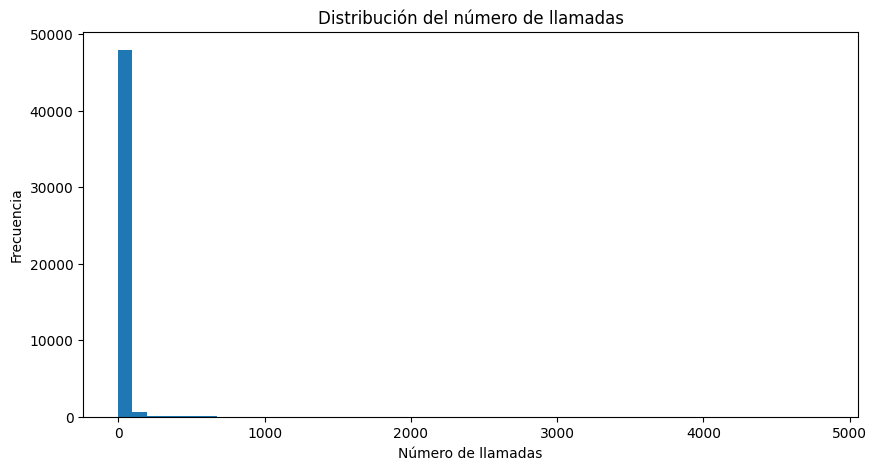

In [165]:
# calls_count
plt.figure(figsize=(10, 5))
plt.hist(df['calls_count'], bins=50)
plt.title('Distribución del número de llamadas')
plt.xlabel('Número de llamadas')
plt.ylabel('Frecuencia')
plt.show()

In [166]:
# Vamos a utilizar el percentil 99
df[['calls_count', 'call_duration', 'total_call_duration']].quantile(0.99)

calls_count              165.00
call_duration          10314.91
total_call_duration    12956.00
Name: 0.99, dtype: float64

Esto nos dirá cuál es el valor por debajo del cual se encuentra aproximadamente el 99% de las observaciones y nos permitirá ver mucho mejor cómo se comporta la gran mayoría de los registros.

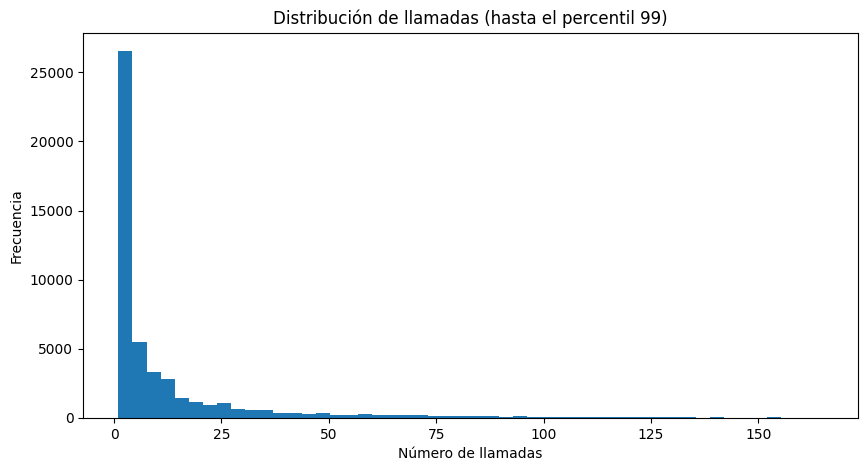

In [167]:
q99_calls = df['calls_count'].quantile(0.99)
plt.figure(figsize=(10, 5))
plt.hist(df[df['calls_count'] <= q99_calls]['calls_count'], bins=50)
plt.title('Distribución de llamadas (hasta el percentil 99)')
plt.xlabel('Número de llamadas')
plt.ylabel('Frecuencia')
plt.show()

La distribución del número de llamadas está fuertemente sesgada hacia la derecha. La mayoría de los registros corresponden a un número relativamente bajo de llamadas, mientras que una pequeña proporción concentra valores muy elevados. Para facilitar la visualización se excluyeron temporalmente los valores superiores al percentil 99, sin eliminarlos del dataset utilizado para el análisis.

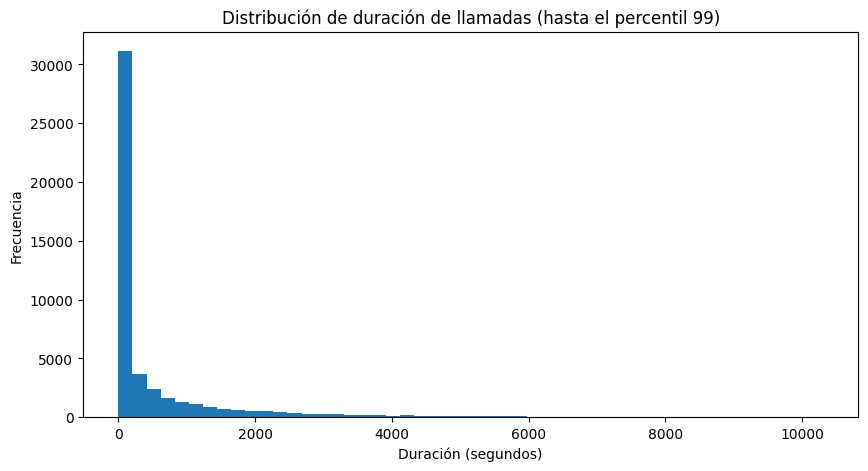

In [168]:
# Call_duration
q99_duration = df['call_duration'].quantile(0.99)
plt.figure(figsize=(10, 5))
plt.hist(df[df['call_duration'] <= q99_duration]['call_duration'], bins=50)
plt.title('Distribución de duración de llamadas (hasta el percentil 99)')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.show()


La duración de las llamadas presenta una distribución fuertemente sesgada hacia la derecha. La mayoría de las llamadas tienen una duración relativamente corta, mientras que una proporción reducida presenta duraciones considerablemente mayores. Para facilitar la visualización se limitaron temporalmente los valores al percentil 99, manteniendo los registros originales para el análisis.

In [169]:
# Calcular el tiempo de espera
df['waiting_time'] = (df['total_call_duration'] - df['call_duration'])

In [170]:
# Validación de tiempos de espera negativos
(df['waiting_time'] < 0).sum()

0

In [171]:
df['waiting_time'].describe(percentiles=[.25, .5, .75, .9, .95, .99])

count    49002.000000
mean       290.276111
std       1132.155291
min          0.000000
25%         17.000000
50%         55.000000
75%        200.000000
90%        613.000000
95%       1163.000000
99%       3157.910000
max      46474.000000
Name: waiting_time, dtype: float64

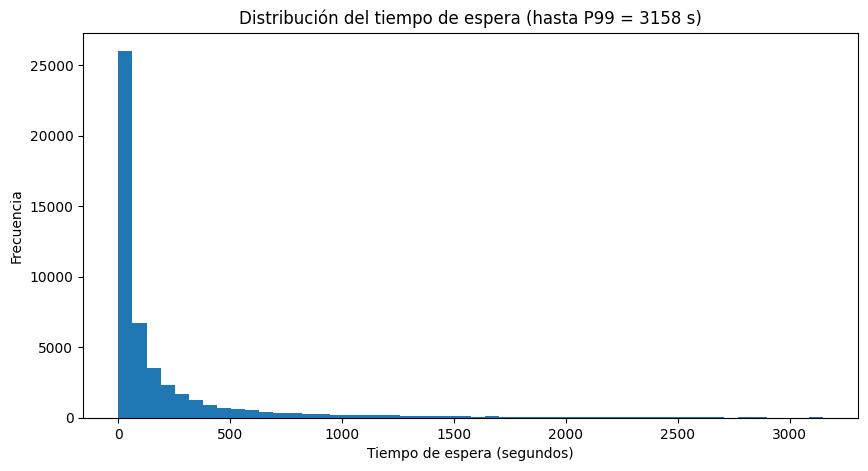

In [172]:
# Grafica para tiempo de espera
q99_waiting = df['waiting_time'].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(
    df[df['waiting_time'] <= q99_waiting]['waiting_time'],
    bins=50
)

plt.title(
    f'Distribución del tiempo de espera (hasta P99 = {q99_waiting:.0f} s)'
)
plt.xlabel('Tiempo de espera (segundos)')
plt.ylabel('Frecuencia')
plt.show()

El tiempo de espera presenta una distribución fuertemente sesgada hacia la derecha. La mayoría de los registros tienen tiempos de espera relativamente bajos, mientras que una proporción reducida presenta valores considerablemente mayores. Para facilitar la visualización se limitaron temporalmente los valores al percentil 99, sin eliminar estos registros del conjunto de datos.

In [173]:
# Creación de la variable de llamadas perdidas
df['missed_calls_count'] = (df['calls_count'].where(df['is_missed_call'], 0))

In [174]:
df['missed_calls_count'].sum()

375918

In [175]:
# Cálculo del tiempo total de espera
df['total_waiting_time'] = (df['waiting_time'] * df['calls_count'])

In [176]:
# Agrupación de llamadas entrantes por operador
incoming_operator = (
    df[df['direction'] == 'in']
    .groupby('operator_id')
    .agg(
        incoming_calls=('calls_count', 'sum'),
        missed_incoming_calls=('missed_calls_count', 'sum'),
        total_waiting_time=('total_waiting_time', 'sum')
    )
    .reset_index()
)

In [177]:
# Calcular la tasa de llamdas perdidas por operador
incoming_operator['missed_rate_pct'] = (incoming_operator['missed_incoming_calls']
                                        /incoming_operator['incoming_calls'] * 100).round(2)

In [178]:
# Calcular el tiempo promedio de espera por operador
incoming_operator['avg_waiting_time'] = (incoming_operator['total_waiting_time']
                                         / incoming_operator['incoming_calls'])

In [179]:
incoming_operator.head()

,operator_id,incoming_calls,missed_incoming_calls,total_waiting_time,missed_rate_pct,avg_waiting_time
0,879896.0,58,0,3822,0.0,65.896552
1,879898.0,104,0,4891,0.0,47.028846
2,880020.0,7,0,54,0.0,7.714286
3,880022.0,8,0,112,0.0,14.000000
4,880026.0,24,0,232,0.0,9.666667


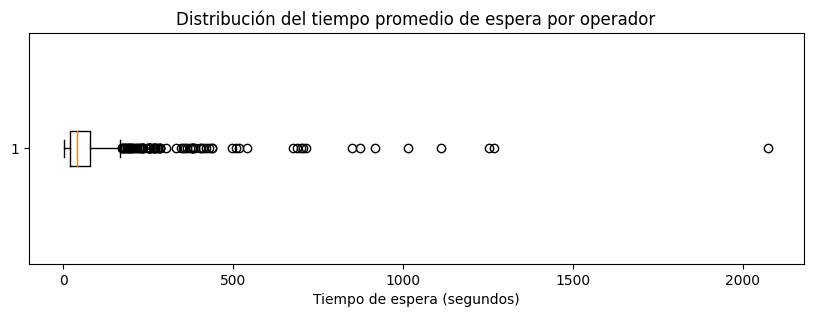

In [180]:
# Tiempo promedio de espera por operador
plt.figure(figsize=(10, 3))
plt.boxplot(incoming_operator['avg_waiting_time'], vert=False)
plt.title('Distribución del tiempo promedio de espera por operador')
plt.xlabel('Tiempo de espera (segundos)')
plt.show()

El tiempo promedio de espera presenta una distribución asimétrica, con una concentración de operadores en valores relativamente bajos y algunos casos con tiempos de espera considerablemente mayores. Estos valores extremos justifican analizar posteriormente el tiempo de espera por operador para identificar posibles casos de ineficiencia.

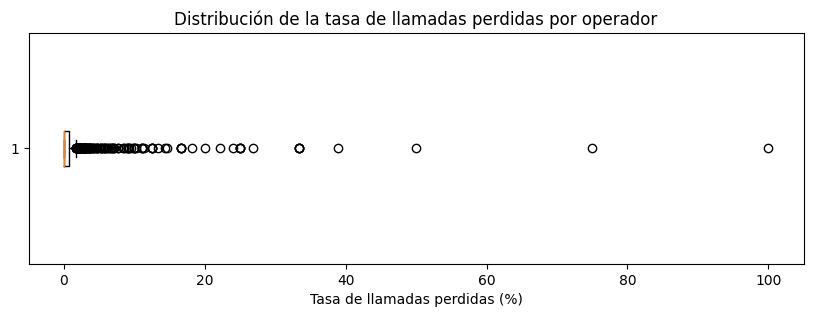

In [181]:
# Tasa de llamadas perdidas por operador
plt.figure(figsize=(10, 3))
plt.boxplot(incoming_operator['missed_rate_pct'], vert=False)
plt.title('Distribución de la tasa de llamadas perdidas por operador')
plt.xlabel('Tasa de llamadas perdidas (%)')
plt.show()

La tasa de llamadas perdidas presenta una distribución altamente asimétrica. La mayoría de los operadores registra tasas bajas, mientras que un grupo reducido presenta valores significativamente mayores. El percentil 90 corresponde a una tasa de 3.7%, que posteriormente se utiliza como referencia para identificar operadores con una tasa de llamadas perdidas elevada.

In [182]:
# Revisar la distribución de las métricas
incoming_operator[
    ['incoming_calls',
     'missed_incoming_calls',
     'missed_rate_pct',
     'avg_waiting_time']
].describe(percentiles=[.25, .5, .75, .9, .95])

,incoming_calls,missed_incoming_calls,missed_rate_pct,avg_waiting_time
count,754.000000,754.000000,754.000000,754.000000
mean,124.405836,1.228117,1.757241,82.622974
std,356.450649,3.797106,6.532345,153.621260
min,1.000000,0.000000,0.000000,1.000000
25%,4.000000,0.000000,0.000000,19.835526
50%,17.000000,0.000000,0.000000,38.911538
75%,78.750000,1.000000,0.675000,78.759651
90%,291.100000,3.000000,3.700000,181.702153
95%,590.250000,6.000000,9.125000,283.478274
max,4766.000000,52.000000,100.000000,2075.848765


### 4.1 Analisis por operador

In [183]:
# Metricas de llamadas salientes por operador
outgoing_operator = (
    df[df['direction'] == 'out']
    .groupby('operator_id')
    .agg(
        outgoing_calls=('calls_count', 'sum')
    )
    .reset_index()
)

In [184]:
outgoing_operator['outgoing_calls'].describe(percentiles=[.25, .5, .75, .9, .95])

count      882.000000
mean       689.731293
std       3122.953946
min          1.000000
25%         11.000000
50%         90.000000
75%        597.250000
90%       1602.900000
95%       2362.950000
max      58977.000000
Name: outgoing_calls, dtype: float64

Esto nos permitirá determinar qué operadores tienen un volumen particularmente bajo de llamadas salientes.

In [185]:
# Integración de métricas por operador
operator_stats = incoming_operator.merge(
    outgoing_operator,
    on='operator_id',
    how='outer'
)

In [186]:
operator_stats.head()

,operator_id,incoming_calls,missed_incoming_calls,total_waiting_time,missed_rate_pct,avg_waiting_time,outgoing_calls
0,879896.0,58.0,0.0,3822.0,0.0,65.896552,872.0
1,879898.0,104.0,0.0,4891.0,0.0,47.028846,7209.0
2,880020.0,7.0,0.0,54.0,0.0,7.714286,38.0
3,880022.0,8.0,0.0,112.0,0.0,14.000000,189.0
4,880026.0,24.0,0.0,232.0,0.0,9.666667,2208.0


In [187]:
# combinar toda la información (Ahora vamos a construir nuestra tabla definitiva de operadores)
outgoing_operator = (
    df[df['direction'] == 'out']
    .groupby('operator_id')
    .agg(
        outgoing_calls=('calls_count', 'sum')
    )
    .reset_index()
)

In [188]:
# Calculamos
operator_stats['has_incoming'] = operator_stats['incoming_calls'].notna()
operator_stats['has_outgoing'] = operator_stats['outgoing_calls'].notna()

In [189]:
# Agrupamos
operator_stats.groupby(['has_incoming', 'has_outgoing']).size()

has_incoming  has_outgoing
False         True            338
True          False           210
              True            544
dtype: int64

In [190]:
# Ahora reemplazamos los valores faltantes por 0
operator_stats[['incoming_calls', 'missed_incoming_calls',
                'total_waiting_time', 'avg_waiting_time',
                'missed_rate_pct', 'outgoing_calls']] = (
    operator_stats[['incoming_calls', 'missed_incoming_calls',
                    'total_waiting_time', 'avg_waiting_time',
                    'missed_rate_pct', 'outgoing_calls']]
    .fillna(0)
)

Ahora reemplazamos los valores faltantes por 0, porque si un operador no aparece en un tipo de llamada significa que no tiene registros de ese tipo.

In [191]:
# Identificar si el operador tiene actividad entrante o saliente
operator_stats['has_incoming'] = operator_stats['incoming_calls'] > 0
operator_stats['has_outgoing'] = operator_stats['outgoing_calls'] > 0

In [192]:
# Clasificamos el tipo de actividad del operador
operator_stats['activity_type'] = np.select(
    [
        (operator_stats['incoming_calls'] > 0) &
        (operator_stats['outgoing_calls'] > 0),

        (operator_stats['incoming_calls'] > 0) &
        (operator_stats['outgoing_calls'] == 0),

        (operator_stats['incoming_calls'] == 0) &
        (operator_stats['outgoing_calls'] > 0)
    ],
    [
        'Entrante y saliente',
        'Solo entrante',
        'Solo saliente'
    ],
    default='Sin actividad'
)

La clasificación nos sirve para aplicar correctamente las métricas, no para descartar operadores.

In [193]:
# Ver cuántos operadores hay en cada grupo
operator_stats['activity_type'].value_counts()

Entrante y saliente    544
Solo saliente          338
Solo entrante          210
Name: activity_type, dtype: int64

In [194]:
# Y tambien en porcentaje
operator_stats['activity_type'].value_counts(normalize=True).mul(100).round(2)

Entrante y saliente    49.82
Solo saliente          30.95
Solo entrante          19.23
Name: activity_type, dtype: float64

In [195]:
# Verificamos que todo esté correcto
operator_stats.groupby('activity_type').agg(
    operators=('operator_id', 'nunique'),
    total_incoming_calls=('incoming_calls', 'sum'),
    total_outgoing_calls=('outgoing_calls', 'sum')
)

,operators,total_incoming_calls,total_outgoing_calls
activity_type,,,
Entrante y saliente,544,87501.0,344397.0
Solo entrante,210,6301.0,0.0
Solo saliente,338,0.0,263946.0


In [196]:
# Analizar específicamente a los que hacen ambas cosas
both_operators = operator_stats[operator_stats['activity_type'] == 'Entrante y saliente'].copy()

In [197]:
# Revisa sus métricas
both_operators[
    ['incoming_calls',
     'missed_incoming_calls',
     'missed_rate_pct',
     'avg_waiting_time',
     'outgoing_calls']
].describe(
    percentiles=[.25, .5, .75, .9, .95]
)

,incoming_calls,missed_incoming_calls,missed_rate_pct,avg_waiting_time,outgoing_calls
count,544.000000,544.000000,544.000000,544.000000,544.000000
mean,160.847426,1.540441,1.822647,97.896714,633.082721
std,412.310273,4.348347,6.835223,176.517453,3693.139779
min,1.000000,0.000000,0.000000,1.200000,1.000000
25%,5.000000,0.000000,0.000000,21.541667,15.000000
50%,24.000000,0.000000,0.000000,43.948684,93.000000
75%,122.500000,1.000000,0.895000,88.433578,426.000000
90%,422.900000,4.000000,3.854000,233.948403,1178.000000
95%,771.950000,7.850000,9.175000,376.146264,2018.150000
max,4766.000000,52.000000,100.000000,2075.848765,58977.000000


### 4.2 Identificación de operadores ineficaces

In [198]:
# definir los operadores potencialmente ineficaces
incoming_active = incoming_operator[incoming_operator['incoming_calls'] >= 20].copy()

In [199]:
print(f'Operadores con al menos 20 llamadas entrantes: {len(incoming_active)}')

Operadores con al menos 20 llamadas entrantes: 356


Para evitar que operadores con un volumen de llamadas demasiado bajo distorsionaran las métricas de desempeño, se estableció un mínimo de 20 llamadas entrantes. Este filtro permite realizar comparaciones más representativas entre operadores sin reducir excesivamente la muestra.

In [200]:
# Analizar los operadores
incoming_active[['missed_rate_pct', 'avg_waiting_time']].describe(percentiles=[.75, .80, .85, .90, .95])

,missed_rate_pct,avg_waiting_time
count,356.000000,356.000000
mean,1.510618,140.515566
std,3.122425,206.581383
min,0.000000,1.708333
50%,0.405000,72.353878
75%,1.720000,150.054473
80%,2.150000,188.867363
85%,2.852500,244.094218
90%,3.700000,285.114472
95%,6.700000,437.859926


In [201]:
# Crear los Umbrales
incoming_active['high_missed_rate'] = (
    incoming_active['missed_rate_pct'] >= 3.7
)

incoming_active['high_waiting_time'] = (
    incoming_active['avg_waiting_time'] >= 285.11
)

In [202]:
# Ahora podemos ver cuántos operadores presentan cada problema
incoming_active[['high_missed_rate', 'high_waiting_time']].sum()

high_missed_rate     37
high_waiting_time    36
dtype: int64

In [203]:
# Crear una puntuación
incoming_active['inefficiency_score'] = (
    incoming_active['high_missed_rate'].astype(int)
    + incoming_active['high_waiting_time'].astype(int)
)

In [204]:
# Comprobar
incoming_active['inefficiency_score'].value_counts().sort_index()

0    284
1     71
2      1
Name: inefficiency_score, dtype: int64

Esto nos permite separar:

0: sin señales fuertes;
1: una señal de posible ineficiencia;
2: señales fuertes en ambas métricas.

In [205]:
# Combinamos con las llamadas salientes (incoming_active con outgoing_operator)
operator_analysis = incoming_active.merge(
    outgoing_operator[['operator_id', 'outgoing_calls']],
    on='operator_id',
    how='left'
)

In [206]:
 operator_analysis.head()

,operator_id,incoming_calls,missed_incoming_calls,total_waiting_time,missed_rate_pct,avg_waiting_time,high_missed_rate,high_waiting_time,inefficiency_score,outgoing_calls
0,879896.0,58,0,3822,0.00,65.896552,False,False,0,872.0
1,879898.0,104,0,4891,0.00,47.028846,False,False,0,7209.0
2,880026.0,24,0,232,0.00,9.666667,False,False,0,2208.0
3,880028.0,63,0,615,0.00,9.761905,False,False,0,2497.0
4,882680.0,99,3,5420,3.03,54.747475,False,False,0,NaN


In [207]:
# Analizar las llamadas salientes que tienen suficiente actividad entrante
operator_analysis['outgoing_calls'].describe(percentiles=[.25, .5, .75, .9, .95])

count      290.000000
mean      1048.524138
std       5014.281606
min          1.000000
25%         59.750000
50%        240.000000
75%        804.000000
90%       1833.000000
95%       2379.500000
max      58977.000000
Name: outgoing_calls, dtype: float64

In [208]:
# Tratamiento de valores faltantes en llamadas salientes
operator_analysis['outgoing_calls'] = (operator_analysis['outgoing_calls'].fillna(0))

In [209]:
# Comprobar cuántos de estos operadores tienen realmente actividad saliente
(operator_analysis['outgoing_calls'] > 0).value_counts()

True     290
False     66
Name: outgoing_calls, dtype: int64

In [210]:
# identificar operadores con baja actividad saliente
operator_analysis['low_outgoing'] = (
    (operator_analysis['outgoing_calls'] > 0) &
    (operator_analysis['outgoing_calls'] <= 11)
)

In [211]:
# también debemos separar a los que tienen cero llamadas salientes
operator_analysis['no_outgoing'] = (operator_analysis['outgoing_calls'] == 0)

In [212]:
# Revisamos
operator_analysis[['low_outgoing', 'no_outgoing']].sum()

low_outgoing    24
no_outgoing     66
dtype: int64

In [213]:
operator_analysis[['low_outgoing', 'no_outgoing']].value_counts()

low_outgoing  no_outgoing
False         False          266
              True            66
True          False           24
dtype: int64

In [214]:
# Crear puntaje
operator_analysis['inefficiency_score'] = (
    operator_analysis['high_missed_rate'].astype(int)
    + operator_analysis['high_waiting_time'].astype(int)
    + operator_analysis['low_outgoing'].astype(int)
)

In [215]:
# Revisamos
operator_analysis['inefficiency_score'].value_counts().sort_index()

0    269
1     77
2     10
Name: inefficiency_score, dtype: int64

In [216]:
# Ranking de operadores por nivel de ineficiencia
operator_analysis.sort_values(
    ['inefficiency_score', 'missed_rate_pct', 'avg_waiting_time'],
    ascending=False
)[
    [
        'operator_id',
        'incoming_calls',
        'missed_incoming_calls',
        'missed_rate_pct',
        'avg_waiting_time',
        'outgoing_calls',
        'inefficiency_score'
    ]
].head(20)

,operator_id,incoming_calls,missed_incoming_calls,missed_rate_pct,avg_waiting_time,outgoing_calls,inefficiency_score
238,937368.0,22,4,18.18,60.590909,10.0,2
102,905862.0,102,15,14.71,66.049020,1.0,2
206,926872.0,24,3,12.50,1.708333,7.0,2
328,951508.0,336,21,6.25,330.020833,146.0,2
161,919206.0,926,9,0.97,686.989201,1.0,2
164,919554.0,1182,11,0.93,675.246193,11.0,2
160,919204.0,1167,9,0.77,1013.559554,9.0,2
158,919164.0,648,3,0.46,497.287037,10.0,2
107,906076.0,24,0,0.00,871.750000,1.0,2
308,944228.0,29,0,0.00,353.137931,5.0,2


In [217]:
# Identificamos esos 10 operadores
operator_analysis['potentially_ineffective'] = (operator_analysis['inefficiency_score'] >= 2)

In [218]:
# Obtener los 10 operadores
potentially_ineffective = operator_analysis[operator_analysis['inefficiency_score'] >= 2].copy()

In [219]:
# Analizamos
potentially_ineffective[
    [
        'operator_id',
        'incoming_calls',
        'missed_incoming_calls',
        'missed_rate_pct',
        'avg_waiting_time',
        'outgoing_calls',
        'high_missed_rate',
        'high_waiting_time',
        'low_outgoing',
        'inefficiency_score'
    ]
].sort_values(
    'inefficiency_score',
    ascending=False
)

,operator_id,incoming_calls,missed_incoming_calls,missed_rate_pct,avg_waiting_time,outgoing_calls,high_missed_rate,high_waiting_time,low_outgoing,inefficiency_score
102,905862.0,102,15,14.71,66.049020,1.0,True,False,True,2
107,906076.0,24,0,0.00,871.750000,1.0,False,True,True,2
158,919164.0,648,3,0.46,497.287037,10.0,False,True,True,2
160,919204.0,1167,9,0.77,1013.559554,9.0,False,True,True,2
161,919206.0,926,9,0.97,686.989201,1.0,False,True,True,2
164,919554.0,1182,11,0.93,675.246193,11.0,False,True,True,2
206,926872.0,24,3,12.50,1.708333,7.0,True,False,True,2
238,937368.0,22,4,18.18,60.590909,10.0,True,False,True,2
308,944228.0,29,0,0.00,353.137931,5.0,False,True,True,2
328,951508.0,336,21,6.25,330.020833,146.0,True,True,False,2


In [220]:
# Ahora necesitamos comprobar si estos 10 operadores representan realmente un grupo con comportamiento diferente.
# Para eso vamos a crear un grupo de comparación
# comparar candidatos contra el resto
operator_analysis.groupby('potentially_ineffective')[
    [
        'missed_rate_pct',
        'avg_waiting_time',
        'outgoing_calls'
    ]
].agg(['count', 'median', 'mean'])


missed_rate_pct                  avg_waiting_time  \
                                  count median      mean            count   
potentially_ineffective                                                     
False                               346  0.385  1.395983              346   
True                                 10  0.950  5.477000               10   

                                                outgoing_calls         \
                             median        mean          count median   
potentially_ineffective                                                 
False                     72.044615  131.408099            346  158.5   
True                     425.212484  455.633901             10    8.0   

                                     
                               mean  
potentially_ineffective              
False                    878.239884  
True                      20.100000

Esto nos permitirá ver si los 10 candidatos realmente tienen un comportamiento diferente del resto de los 346 operadores

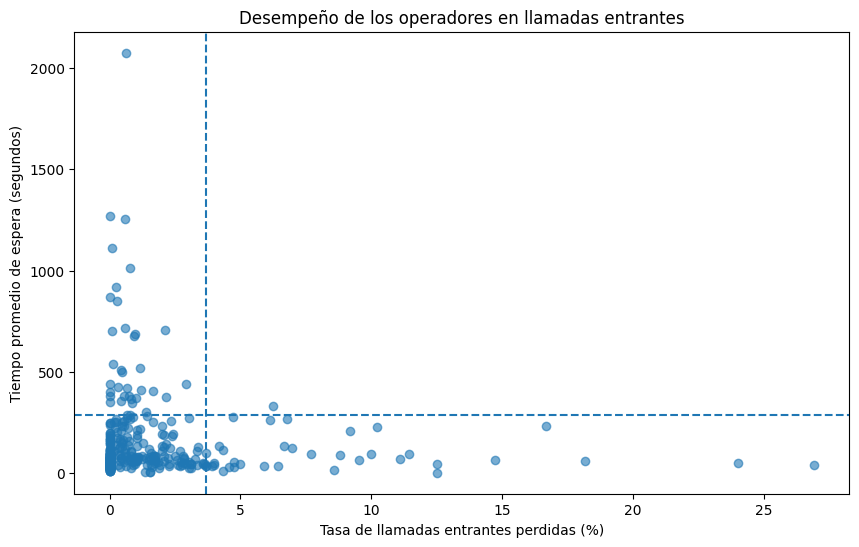

In [221]:
# Grafica de tasa de llamadas perdidas vs. tiempo de espera.
plt.figure(figsize=(10, 6))
plt.scatter(
    operator_analysis['missed_rate_pct'],
    operator_analysis['avg_waiting_time'],
    alpha=0.6
)
plt.axvline(3.7, linestyle='--')
plt.axhline(285.11, linestyle='--')
plt.xlabel('Tasa de llamadas entrantes perdidas (%)')
plt.ylabel('Tiempo promedio de espera (segundos)')
plt.title('Desempeño de los operadores en llamadas entrantes')
plt.show()

El gráfico muestra la relación entre la tasa de llamadas entrantes perdidas y el tiempo promedio de espera. La mayoría de los operadores se concentra en niveles relativamente bajos de ambos indicadores. Sin embargo, algunos operadores presentan simultáneamente una tasa de llamadas perdidas y un tiempo de espera elevados, ubicándose en el cuadrante superior derecho. Estos casos requieren especial atención y se consideran candidatos potenciales para un análisis de ineficiencia.

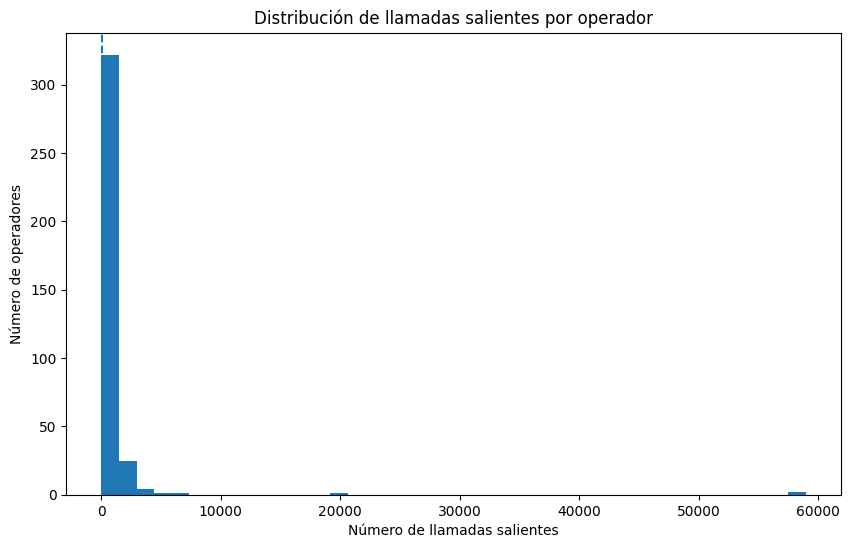

In [222]:
# Gráfico para las llamadas salientes por operador
plt.figure(figsize=(10, 6))
plt.hist(operator_analysis['outgoing_calls'],bins=40)
plt.axvline(11, linestyle='--')
plt.xlabel('Número de llamadas salientes')
plt.ylabel('Número de operadores')
plt.title('Distribución de llamadas salientes por operador')
plt.show()

La actividad de llamadas salientes presenta una distribución fuertemente sesgada hacia la derecha y una alta variabilidad entre operadores. La mayoría registra un volumen relativamente bajo o moderado de llamadas, mientras que algunos operadores concentran una actividad mucho mayor. Se estableció como referencia de baja actividad un máximo de 11 llamadas salientes, correspondiente aproximadamente al percentil 25 de los operadores analizados.

In [223]:
# Tabla para presentar los candidatos.
potentially_ineffective[
    [
        'operator_id',
        'incoming_calls',
        'missed_incoming_calls',
        'missed_rate_pct',
        'avg_waiting_time',
        'outgoing_calls',
        'inefficiency_score'
    ]
].sort_values(
    ['inefficiency_score', 'missed_rate_pct', 'avg_waiting_time'],
    ascending=False
)

,operator_id,incoming_calls,missed_incoming_calls,missed_rate_pct,avg_waiting_time,outgoing_calls,inefficiency_score
238,937368.0,22,4,18.18,60.590909,10.0,2
102,905862.0,102,15,14.71,66.049020,1.0,2
206,926872.0,24,3,12.50,1.708333,7.0,2
328,951508.0,336,21,6.25,330.020833,146.0,2
161,919206.0,926,9,0.97,686.989201,1.0,2
164,919554.0,1182,11,0.93,675.246193,11.0,2
160,919204.0,1167,9,0.77,1013.559554,9.0,2
158,919164.0,648,3,0.46,497.287037,10.0,2
107,906076.0,24,0,0.00,871.750000,1.0,2
308,944228.0,29,0,0.00,353.137931,5.0,2


In [224]:
# Clasifiquemos los 10 operadores
def classify_operator(row):
    problems = []

    if row['high_missed_rate']:
        problems.append('alta tasa de llamadas perdidas')

    if row['high_waiting_time']:
        problems.append('alto tiempo de espera')

    if row['low_outgoing']:
        problems.append('baja actividad saliente')

    return ' + '.join(problems)


potentially_ineffective['problem_type'] = (
    potentially_ineffective.apply(classify_operator, axis=1)
)

In [225]:
# Mostrar 
potentially_ineffective[
    [
        'operator_id',
        'problem_type',
        'missed_rate_pct',
        'avg_waiting_time',
        'outgoing_calls'
    ]
].sort_values('operator_id')

,operator_id,problem_type,missed_rate_pct,avg_waiting_time,outgoing_calls
102,905862.0,alta tasa de llamadas perdidas + baja activida...,14.71,66.049020,1.0
107,906076.0,alto tiempo de espera + baja actividad saliente,0.00,871.750000,1.0
158,919164.0,alto tiempo de espera + baja actividad saliente,0.46,497.287037,10.0
160,919204.0,alto tiempo de espera + baja actividad saliente,0.77,1013.559554,9.0
161,919206.0,alto tiempo de espera + baja actividad saliente,0.97,686.989201,1.0
164,919554.0,alto tiempo de espera + baja actividad saliente,0.93,675.246193,11.0
206,926872.0,alta tasa de llamadas perdidas + baja activida...,12.50,1.708333,7.0
238,937368.0,alta tasa de llamadas perdidas + baja activida...,18.18,60.590909,10.0
308,944228.0,alto tiempo de espera + baja actividad saliente,0.00,353.137931,5.0
328,951508.0,alta tasa de llamadas perdidas + alto tiempo d...,6.25,330.020833,146.0


Se identificaron 10 operadores con al menos dos señales de posible ineficiencia. Sin embargo, los problemas observados no son homogéneos. Tres operadores presentan una elevada tasa de llamadas entrantes perdidas y baja actividad saliente; seis presentan tiempos de espera elevados junto con baja actividad saliente; y un operador presenta simultáneamente una elevada tasa de llamadas perdidas y un tiempo de espera elevado.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b><br><br>Excelente la identificación de operadores ineficaces, es el corazón del proyecto y está muy bien resuelta. Aplicás un mínimo de 20 llamadas entrantes para no distorsionar las tasas con volúmenes chicos, definís los umbrales con el percentil 90 de cada métrica en lugar de valores fijos (perdidas ≥3.7%, espera ≥285 segundos, salientes ≤11), y marcás como ineficaz al operador que presenta al menos dos de las tres señales. Con eso llegás a 10 operadores, el 2.81% del total. Y das un paso más al clasificarlos según qué combinación de problemas presentan, lo que hace el resultado mucho más accionable para un supervisor.
</div>

In [226]:
# Tabla resumen (así sabremos exactamente cuántos operadores tenemos en cada categoría.)
potentially_ineffective['problem_type'].value_counts()

alto tiempo de espera + baja actividad saliente             6
alta tasa de llamadas perdidas + baja actividad saliente    3
alta tasa de llamadas perdidas + alto tiempo de espera      1
Name: problem_type, dtype: int64

In [227]:
# Tabla final de candidatos
final_candidates = operator_analysis[
    operator_analysis['inefficiency_score'] >= 2
][
    [
        'operator_id',
        'incoming_calls',
        'missed_incoming_calls',
        'missed_rate_pct',
        'avg_waiting_time',
        'outgoing_calls',
        'high_missed_rate',
        'high_waiting_time',
        'low_outgoing',
        'inefficiency_score'
    ]
].sort_values(
    ['inefficiency_score', 'missed_rate_pct', 'avg_waiting_time'],
    ascending=False
)

final_candidates

,operator_id,incoming_calls,missed_incoming_calls,missed_rate_pct,avg_waiting_time,outgoing_calls,high_missed_rate,high_waiting_time,low_outgoing,inefficiency_score
238,937368.0,22,4,18.18,60.590909,10.0,True,False,True,2
102,905862.0,102,15,14.71,66.049020,1.0,True,False,True,2
206,926872.0,24,3,12.50,1.708333,7.0,True,False,True,2
328,951508.0,336,21,6.25,330.020833,146.0,True,True,False,2
161,919206.0,926,9,0.97,686.989201,1.0,False,True,True,2
164,919554.0,1182,11,0.93,675.246193,11.0,False,True,True,2
160,919204.0,1167,9,0.77,1013.559554,9.0,False,True,True,2
158,919164.0,648,3,0.46,497.287037,10.0,False,True,True,2
107,906076.0,24,0,0.00,871.750000,1.0,False,True,True,2
308,944228.0,29,0,0.00,353.137931,5.0,False,True,True,2


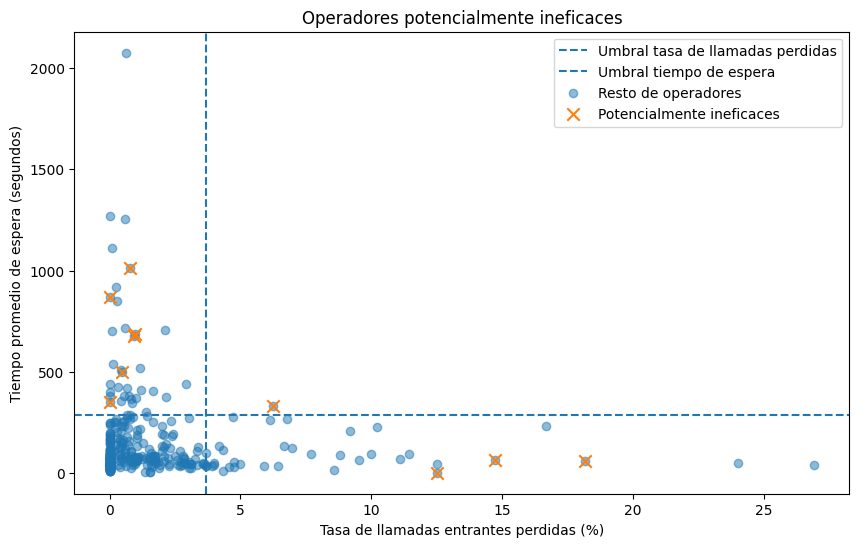

In [228]:
# Graficar directamente los 10 operadores potencialmente ineficaces
plt.figure(figsize=(10, 6))

# Todos los operadores
plt.scatter(
    operator_analysis['missed_rate_pct'],
    operator_analysis['avg_waiting_time'],
    alpha=0.5,
    label='Resto de operadores'
)

# Operadores potencialmente ineficaces
plt.scatter(
    potentially_ineffective['missed_rate_pct'],
    potentially_ineffective['avg_waiting_time'],
    marker='x',
    s=80,
    label='Potencialmente ineficaces'
)

# Umbrales
plt.axvline(
    3.7,
    linestyle='--',
    label='Umbral tasa de llamadas perdidas'
)

plt.axhline(
    285.11,
    linestyle='--',
    label='Umbral tiempo de espera'
)

plt.xlabel('Tasa de llamadas entrantes perdidas (%)')
plt.ylabel('Tiempo promedio de espera (segundos)')
plt.title('Operadores potencialmente ineficaces')
plt.legend()

plt.show()

El gráfico permite identificar visualmente a los operadores potencialmente ineficaces a partir de los umbrales establecidos para la tasa de llamadas perdidas (3.7%) y el tiempo promedio de espera (285.11 s). Los operadores marcados presentan un desempeño desfavorable en al menos dos de los indicadores utilizados para evaluar su eficiencia.

In [235]:
# Comparación de indicadores entre operadores potencialmente ineficaces y el resto
comparison_plot = operator_analysis.copy()

comparison_plot['group'] = comparison_plot[
    'potentially_ineffective'
].map({
    True: 'Potencialmente ineficaces',
    False: 'Resto de operadores'


})

comparison_plot.groupby('group')[
    ['missed_rate_pct', 'avg_waiting_time', 'outgoing_calls']
].median()

,missed_rate_pct,avg_waiting_time,outgoing_calls
group,,,
Potencialmente ineficaces,0.950,425.212484,8.0
Resto de operadores,0.385,72.044615,158.5


Los operadores potencialmente ineficaces presentan una tasa mediana de llamadas perdidas de 0.95%, un tiempo de espera de 425.21 segundos y 8 llamadas salientes, frente a 0.385%, 72.04 segundos y 266.5 llamadas, respectivamente, en el resto de los operadores. Esto evidencia un desempeño considerablemente menos favorable en los tres indicadores.

## Paso 5. Pruebas de hipótesis estadísticas

Tenemos dos grupos:

Grupo 1: 10 operadores potencialmente ineficaces.
Grupo 2: 346 operadores restantes.

Vamos a comprobar si sus distribuciones son significativamente diferentes.

usaremos un nivel de significancia: alpha = 0.05

La interpretación será:

p < 0.05 → rechazamos H₀.
p >= 0.05 → no rechazamos H₀.

In [230]:
# Clasificación de operadores según nivel de ineficiencia
ineffective = operator_analysis[operator_analysis['inefficiency_score'] >= 2]
effective = operator_analysis[operator_analysis['inefficiency_score'] < 2]

print('Operadores potencialmente ineficaces:', len(ineffective))
print('Resto de operadores:', len(effective))

Operadores potencialmente ineficaces: 10
Resto de operadores: 346


In [231]:
# 1. Tasa de llamadas perdidas
stat_missed, p_missed = mannwhitneyu(
    ineffective['missed_rate_pct'],
    effective['missed_rate_pct'],
    alternative='greater'
)

print('U:', stat_missed)
print('p-value:', p_missed)

U: 2352.0
p-value: 0.021383568774746196


Se rechaza la hipotesis nula, existe evidencia estadísticamente significativa de que los operadores identificados como potencialmente ineficaces presentan una tasa de llamadas entrantes perdidas mayor que el resto de operadores.

In [232]:
# 2. Tiempo de espera
stat_wait, p_wait = mannwhitneyu(
    ineffective['avg_waiting_time'],
    effective['avg_waiting_time'],
    alternative='greater'
)

print('U:', stat_wait)
print('p-value:', p_wait)

U: 2629.0
p-value: 0.002551122988568887


Se rechaza la hipotesis nula, existe evidencia estadísticamente significativa de que los operadores potencialmente ineficaces presentan tiempos de espera mayores.

In [233]:
# 3. Llamadas salientes
stat_out, p_out = mannwhitneyu(
    ineffective['outgoing_calls'],
    effective['outgoing_calls'],
    alternative='less'
)

print('U:', stat_out)
print('p-value:', p_out)

U: 842.5
p-value: 0.002772494026947089


Se rechaza la hipotesis nula, existe evidencia estadísticamente significativa de que los operadores potencialmente ineficaces realizan menos llamadas salientes que el resto.

Con un nivel de significancia de α = 0.05, las tres pruebas de Mann–Whitney mostraron diferencias estadísticamente significativas entre los operadores potencialmente ineficaces y el resto de operadores. Los candidatos presentaron una mayor tasa de llamadas perdidas, un mayor tiempo de espera y un menor volumen de llamadas salientes.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b><br><br>Muy bien las pruebas de hipótesis. Elegís correctamente la prueba de Mann-Whitney por el sesgo de las distribuciones, y las tres comparaciones (tasa de perdidas, tiempo de espera y llamadas salientes) resultan significativas con un alfa de 0.05, confirmando que los dos grupos se comportan de forma distinta.<br><br>Un matiz metodológico para tener en cuenta, no cambia la aprobación. Como los 10 operadores fueron seleccionados justamente por tener valores extremos en estas mismas métricas, las pruebas casi con seguridad iban a dar significativas, porque comparás un grupo elegido por ser extremo contra el resto. La prueba confirma que los grupos difieren, que es útil, pero conviene aclarar en el texto que no es una validación independiente de los criterios de selección. Un buen ejercicio sería, por ejemplo, contrastar una métrica distinta a las usadas para armar el grupo.
</div>

In [234]:
# Qué porcentaje de los 356 operadores terminó siendo identificado como candidato
candidate_percentage = (len(potentially_ineffective) / len(operator_analysis) * 100)
print(f'{candidate_percentage:.2f}%')

2.81%


Solo alrededor del 2.8% de los operadores evaluados fueron identificados como potencialmente ineficaces.

#### Identificación de operadores potencialmente ineficaces.

Para identificar operadores potencialmente ineficaces se analizaron 356 operadores con al menos 20 llamadas entrantes, utilizando como referencia el percentil 90 de las métricas de desempeño.

Se consideraron como señales de posible ineficiencia una tasa de llamadas perdidas igual o superior al 3.7%, un tiempo promedio de espera igual o superior a 285.11 segundos y una baja actividad saliente, definida como 11 llamadas o menos.

Con estos criterios se identificaron 10 operadores potencialmente ineficaces, equivalentes al 2.81% de los operadores evaluados.

Los candidatos se clasificaron según las señales presentadas:

6 operadores: alto tiempo de espera + baja actividad saliente.
3 operadores: alta tasa de llamadas perdidas + baja actividad saliente.
1 operador: alta tasa de llamadas perdidas + alto tiempo de espera.

#### Limitaciones del análisis.

Se excluyeron operadores con menos de 20 llamadas entrantes para evitar que porcentajes calculados sobre volúmenes muy pequeños distorsionaran la identificación de casos problemáticos.
Las métricas presentan distribuciones sesgadas y valores extremos, por lo que se utilizaron medidas como la mediana y la prueba no paramétrica de Mann–Whitney.
La identificación de operadores potencialmente ineficaces se basa en criterios derivados de la distribución de los datos y debe interpretarse como una herramienta de priorización para los supervisores, no como una evaluación definitiva del desempeño individual.

## Paso 6. Conclusion

Durante el análisis de los datos de CallMeMaybe se realizó una limpieza y validación de la información, eliminando registros duplicados y verificando la consistencia de las variables relacionadas con las llamadas. Después del procesamiento se trabajó con 49,002 registros, correspondientes a 307 clientes y 1,092 operadores.

Para identificar operadores potencialmente ineficaces se seleccionaron aquellos con al menos 20 llamadas entrantes, obteniendo 356 operadores. Se establecieron tres indicadores: una tasa elevada de llamadas entrantes perdidas (≥3.7%), un tiempo medio de espera elevado (≥285.11 segundos) y una baja actividad saliente (1–11 llamadas). Los operadores que presentaron al menos dos de estos indicadores fueron considerados potencialmente ineficaces.

Como resultado, se identificaron 10 operadores, equivalentes al 2.81% de los operadores analizados. Los problemas encontrados no fueron iguales para todos: algunos presentaron una alta proporción de llamadas perdidas, mientras que otros destacaron por tiempos de espera elevados y baja actividad saliente.

Las pruebas de Mann–Whitney mostraron diferencias estadísticamente significativas entre los operadores potencialmente ineficaces y el resto para la tasa de llamadas perdidas (p=0.0214), el tiempo de espera (p=0.00255) y las llamadas salientes (p=0.00277). Estos resultados respaldan que el grupo identificado presenta un comportamiento significativamente diferente en los indicadores analizados.

Recomendaciones: se recomienda realizar una revisión individual de los 10 operadores identificados, analizar las causas de sus resultados y proporcionar capacitación específica cuando sea necesario. También sería conveniente monitorear periódicamente la tasa de llamadas perdidas, los tiempos de espera y la actividad saliente mediante indicadores de desempeño. Finalmente, los operadores no deberían considerarse automáticamente como ineficaces únicamente por estos resultados, sino como casos prioritarios para una revisión más detallada, considerando factores como la carga de trabajo, los horarios y las características de las llamadas.

En conclusión, el análisis permitió identificar un grupo reducido de operadores que requiere atención y proporcionó indicadores cuantitativos que pueden utilizarse para mejorar el seguimiento del desempeño y la calidad del servicio de CallMeMaybe.


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b><br><br>Muy buen cierre. La conclusión resume con claridad todo el recorrido (de los 53.902 registros iniciales a los 49.002 analizados, los 356 operadores evaluados y los 10 identificados), y valoro especialmente la sección de limitaciones: reconocés el efecto del mínimo de actividad, el sesgo de las distribuciones y, sobre todo, que la identificación es una herramienta de priorización para los supervisores y no una evaluación definitiva del desempeño. Esa honestidad sobre el alcance del análisis demuestra mucha madurez. Un proyecto muy completo y bien argumentado de principio a fin.
</div>